# Effect of Lattice on Tweezered Atoms
Jeff

Basic scattering calculations to see the effect of lattice light on T1 and T2 decoherence of atoms in tweezers

### Basic Scattering Assumptions, copied from MOTScattering.ipynb

In [1]:
### Useful functions
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import arc
from get_polarizability import *

# constants
h = 6.62607015e-34  # Planck's constant in J*s
hbar = h / (2 * np.pi)  # reduced Planck's constant
c = 299792458  # speed of light in m/s
epsilon_0 = 8.854187817e-12  # vacuum permittivity in F/m
a0 = 5.29177210903e-11  # Bohr radius in meters
e = 1.602176634e-19  # elementary charge in Coulombs
me = 9.10938356e-31  # electron mass in kg
kB = 1.380649e-23  # Boltzmann constant in J/K

# Cs information
Cs_D1_wavelength = 894.592959e-9  # Cs D1 line wavelength in meters
Cs_D1_frequency = c / Cs_D1_wavelength  # Cs D1 line frequency in Hz
Cs_D1_gamma = 4.5612e6 # Cs D1 line natural linewidth in Hz
Cs_D1_pi_Isat = 2.4981*10  # Cs D1 line pi-polarized saturation intensity in W/m^2

Cs_D2_wavelength = 852.34727582e-9  # Cs D2 line wavelength in meters
Cs_D2_frequency = c / Cs_D2_wavelength  # Cs D2 line frequency in Hz
Cs_D2_gamma = 5.2227e6 # Cs D2 line natural linewidth in Hz
Cs_D2_pi_Isat = 1.6536*10  # Cs D2 line pi-polarized saturation intensity in W/m^2
Cs_D2_iso_Isat = 2.7059*10  # Cs D2 line isotropic saturation intensity in W/m^2
Cs_D2_sigma_Isat = 1.1023*10  # Cs D2 line sigma-polarized saturation intensity in W/m^2

# Rb information
Rb_D1_wavelength = 794.978850e-9      # Rb D1 line wavelength in meters
Rb_D1_frequency = c / Rb_D1_wavelength  # Rb D1 line frequency in Hz
Rb_D1_gamma = 5.746e6 # Rb D1 line natural linewidth in Hz
Rb_D1_pi_Isat = 4.484*10  # Rb D1 line pi-polarized saturation intensity in W/m^2

Rb_D2_wavelength = 780.241209686e-9  # Rb D2 line wavelength in meters
Rb_D2_frequency = c / Rb_D2_wavelength  # Rb D2 line frequency in Hz
Rb_D2_gamma = 6.065e6 # Rb D2 line natural linewidth in Hz
Rb_D2_pi_Isat = 2.503*10  # Rb D2 line pi-polarized saturation intensity in W/m^2
Rb_D2_iso_Isat = 3.576*10  # Rb D2 line isotropic saturation intensity in W/m^2
Rb_D2_sigma_Isat = 1.669*10  # Rb D2 line sigma-polarized saturation intensity in W/m^2

In [2]:
def calc_scattering_rate(I, I_sat, delta, gamma):
    """
    Calculate the scattering rate of an atom given the laser intensity,
    saturation intensity, detuning, and natural linewidth.

    Parameters:
    I (float): Laser intensity
    I_sat (float): Saturation intensity
    delta (float): Detuning from resonance (in Hz)
    gamma (float): Natural linewidth of the transition (in Hz)

    Returns:
    float: Scattering rate (in Hz)
    """
    s = I / I_sat  # Saturation parameter
    scattering_rate = np.pi * gamma * (s / (1 + s + (2 * delta / gamma) ** 2)) # from Amanda's code - ist this correct? - yes
    return scattering_rate

def intensity_from_rate(Rsc, distance, frequency):
    # Each photon has energy hv, so power = Rsc * hv
    power = Rsc * h * frequency
    return power/(4*np.pi*(distance**2))

def interaction_cross_section(I, I_sat, delta, gamma, wavelength):
    sigma_0 = 3*wavelength**2/(2*np.pi)
    return sigma_0 / (1 + ((2*delta/gamma)**2) + I/I_sat)

In [3]:
# Rb Experiment parameters (D2 line)
Rb_MOT_detuning = 17e6 # Hz, from Atom Array 2
Rb_MOT_intensity = 0.01/(4*np.pi*(0.1e-3)**2) # W/m^2, from Atom Array 2 assuming 0.2 mm MOT diameter
Rb_MOT_temperature = 50e-6 # uK
transport_distance = 30e-2 # m
aperature_radius = 1e-2 # m
Rb_tweezer_depth = 0.8 #mK
Rb_tweezer_wavelength = 809e-9
Rb_tweezer_frequency = c/Rb_tweezer_wavelength #809 nm tweezers
Rb_tweezer_intensity = 6e-3/(4*np.pi*(0.5e-6)**2) # W/m^2, 6mW per beam, 0.5 um waist

Rb_MOT_frequency = Rb_D2_frequency - Rb_MOT_detuning
Rb_R_MOT = calc_scattering_rate(Rb_MOT_intensity, Rb_D2_pi_Isat, Rb_MOT_detuning, Rb_D2_gamma)
Rb_I_MOT = intensity_from_rate(Rb_R_MOT, transport_distance, Rb_MOT_frequency)
Rb_I_at_atoms = Rb_I_MOT * (aperature_radius**2)/(transport_distance**2) #assume aperature << SA of emission at transport distance
pol_conversion = 4*np.pi*epsilon_0*(a0**3)
Rb_Ufe = (-1*get_polarizability(Rb_tweezer_wavelength, atom="Rb", orbital="5p3")* pol_conversion/(2*c*epsilon_0))*Rb_tweezer_intensity
Rb_Ufg = (-1*get_polarizability(Rb_tweezer_wavelength, atom="Rb", orbital="5s")* pol_conversion/(2*c*epsilon_0))*Rb_tweezer_intensity
Rb_D2freq_shift = (Rb_Ufe-Rb_Ufg)/h #shift of D2 line in tweezers
Rb_D2freq_in_tweezer = Rb_D2_frequency+Rb_D2freq_shift
Rb_R_D2_tweezer = calc_scattering_rate(Rb_I_at_atoms, Rb_D2_pi_Isat, Rb_MOT_frequency-Rb_D2freq_in_tweezer, Rb_D2_gamma)
Rb_xc_tweezer = interaction_cross_section(Rb_I_at_atoms, Rb_D2_pi_Isat, Rb_MOT_frequency-Rb_D2freq_in_tweezer, Rb_D2_gamma, c/Rb_MOT_frequency)
Rb_flux_tweezer = Rb_R_D2_tweezer/Rb_xc_tweezer
print(f"Rb87 scattering rate off MOT (photons/s): {Rb_R_MOT}")
print(f"Rb87 D2 detuning in tweezers (Hz): {Rb_D2freq_shift}")
print(f"MOT light intensity at atoms {Rb_I_MOT}")
print(f"Rb87 scattering rate in tweezers off D2 line (photons/s): {Rb_R_D2_tweezer}")
print(f"Rb87 flux through atom cross section (photons/s*interaction xc): {Rb_flux_tweezer}")
print(f"Rb87 avg time before 1 MOT photon bothers tweezer atom (s): {1/Rb_flux_tweezer}")

Rb87 scattering rate off MOT (photons/s): 18861386.23112317
Rb87 D2 detuning in tweezers (Hz): -3368901.3439596226
MOT light intensity at atoms 4.245893177105156e-12
Rb87 scattering rate in tweezers off D2 line (photons/s): 1.6935846863492486e-10
Rb87 flux through atom cross section (photons/s*interaction xc): 12355.12627607395
Rb87 avg time before 1 MOT photon bothers tweezer atom (s): 8.093806389794073e-05


In [4]:
# Cs Experiment parameters (D2 line)
Cs_MOT_detuning = 1e6 # Assume 1GHz
Cs_MOT_intensity = (0.5e-3)/(4*np.pi*(0.1e-3)**2) # W/m^2, from Yichao's thesis assuming 0.2 mm MOT diameter
Cs_MOT_temperature = 50e-6 # uK
transport_distance = 30e-2 # m
aperature_radius = 1e-2 # m
Cs_tweezer_depth = 0.8 #mK
Cs_tweezer_wavelength = 1064e-9
Cs_tweezer_frequency = c/Cs_tweezer_wavelength #1064 nm tweezers
Cs_tweezer_intensity = 46e-3/(4*np.pi*(0.5e-6)**2) # W/m^2, 46mW per beam, 0.5 um waist

Cs_MOT_frequency = Cs_D2_frequency - Cs_MOT_detuning
Cs_R_MOT = calc_scattering_rate(Cs_MOT_intensity, Cs_D2_pi_Isat, Cs_MOT_detuning, Cs_D2_gamma)
Cs_I_MOT = intensity_from_rate(Cs_R_MOT, transport_distance, Cs_MOT_frequency)
Cs_I_at_atoms = Cs_I_MOT * (aperature_radius**2)/(transport_distance**2) #assume aperature << SA of emission at transport distance
pol_conversion = 4*np.pi*epsilon_0*(a0**3)
Cs_Ufe = (-1*get_polarizability(Cs_tweezer_wavelength, atom="Cs", orbital="6p3")* pol_conversion/(2*c*epsilon_0))*Cs_tweezer_intensity
Cs_Ufg = (-1*get_polarizability(Cs_tweezer_wavelength, atom="Cs", orbital="6s")* pol_conversion/(2*c*epsilon_0))*Cs_tweezer_intensity
Cs_D2freq_shift = (Cs_Ufe-Cs_Ufg)/h #shift of D2 line in tweezers
Cs_D2freq_in_tweezer = Cs_D2_frequency+Cs_D2freq_shift
Cs_R_D2_tweezer = calc_scattering_rate(Cs_I_at_atoms, Cs_D2_pi_Isat, Cs_MOT_frequency-Cs_D2freq_in_tweezer, Cs_D2_gamma)
Cs_xc_tweezer = interaction_cross_section(Cs_I_at_atoms, Cs_D2_pi_Isat, Cs_MOT_frequency-Cs_D2freq_in_tweezer, Cs_D2_gamma, c/Cs_MOT_frequency)
Cs_flux_tweezer = Cs_R_D2_tweezer/Cs_xc_tweezer
print(f"Cs scattering rate off MOT (photons/s): {Cs_R_MOT}")
print(f"Cs D2 detuning in tweezers (Hz): {Cs_D2freq_shift}")
print(f"Cs scattering rate in tweezers off D2 line (photons/s): {Cs_R_D2_tweezer}")
print(f"Cs flux through atom cross section (photons/s*interaction xc): {Cs_flux_tweezer}")
print(f"Cs avg time before 1 MOT photon bothers tweezer atom (s): {1/Cs_flux_tweezer}")

Cs scattering rate off MOT (photons/s): 16329777.978949651
Cs D2 detuning in tweezers (Hz): -15808252.21701667
Cs scattering rate in tweezers off D2 line (photons/s): 1.1188785773593679e-10
Cs flux through atom cross section (photons/s*interaction xc): 10695.115923208901
Cs avg time before 1 MOT photon bothers tweezer atom (s): 9.350062282447573e-05


## Lattice Stuff

In [5]:
# We are interested in the radial profile of a Gaussian beam at a fixed distance along its (axial) propagation axis
# Just copying the wiki definition https://en.wikipedia.org/wiki/Gaussian_beam
def I_slice(z_absolute, zf, r, power=18, w0=180e-6, n=1, wavelength=1064e-9):
    z = zf - z_absolute
    I0 = (2*power)/(np.pi * w0**2)
    zR = np.pi*(w0**2)*n/wavelength
    w_z = w0 * np.sqrt(1 + (z/zR)**2)
    I_r = I0 * (w0/w_z)**2 * np.exp((-2*r**2)/w_z**2)
    return I_r

def I_tot(z_absolute, zf, r, transport_distance, power=18, w0=180e-6, n=1, wavelength=1064e-9):
    Ir1 = I_slice(z_absolute, zf, r, power=power, w0=w0, wavelength=wavelength)
    Ir2 = I_slice(z_absolute, transport_distance-zf, r, power=power, w0=w0, wavelength=wavelength)
    Ir_tot = Ir1+Ir2
    return Ir_tot

Intensity 1mm from focus is 8452.54995344452 W/m^2


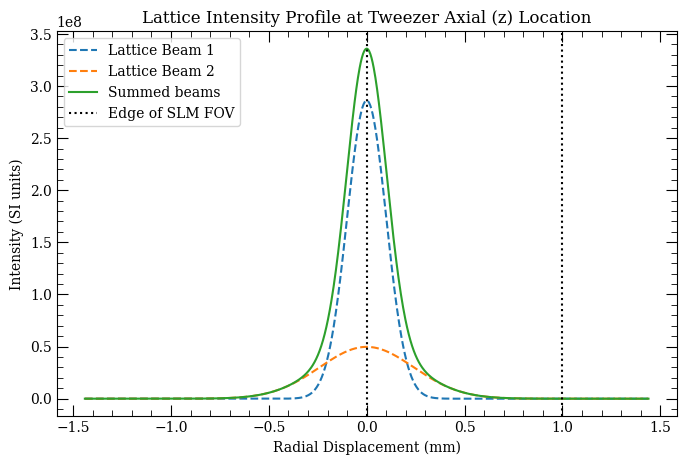

In [6]:
# Normal experiment parameters
power = 18  # power in Watts
waist = 180e-6  # beam waist in meters
transport_distance = 37e-2 # 37 cm from MOT to tweezers
focus = 0.09  # focus position in meters
wavelength = 1064e-9 # 1064 nm
tweezer_z = 43.5e-3 # tweezers are in center of glass cell which is 87 mm wide
r_array = np.linspace(-waist*8, waist*8, 1000)
Ir1 = I_slice(tweezer_z, focus, r_array, power=power, w0=waist, wavelength=wavelength)
Ir2 = I_slice(tweezer_z, transport_distance-focus, r_array, power=power, w0=waist, wavelength=wavelength)
Ir_tot = I_tot(tweezer_z, focus, r_array, transport_distance, power=power, w0=waist, wavelength=wavelength)
plt.figure(figsize=(8,5))
plt.plot(r_array*1e3, Ir1, linestyle='--', label='Lattice Beam 1')
plt.plot(r_array*1e3, Ir2, linestyle='--', label="Lattice Beam 2")
plt.plot(r_array*1e3, Ir_tot, label="Summed beams")
plt.axvline(1, color='black', linestyle='dotted', label="Edge of SLM FOV")
plt.axvline(0, color='black', linestyle='dotted')
plt.legend()
plt.title("Lattice Intensity Profile at Tweezer Axial (z) Location")
plt.ylabel("Intensity (SI units)")
plt.xlabel("Radial Displacement (mm)")
lattice_intensity = I_tot(tweezer_z, focus, 1e-3, transport_distance, power=power, w0=waist, wavelength=wavelength)
print(f"Intensity 1mm from focus is {lattice_intensity} W/m^2")

Text(0.5, 0, 'Radial Displacement (mm)')

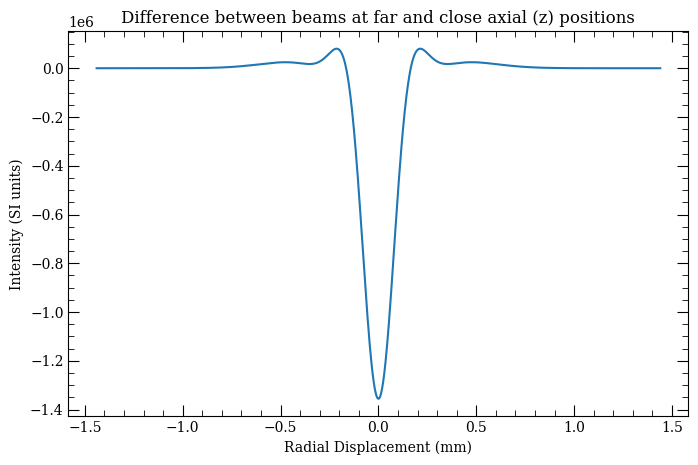

In [7]:
# Normal experiment parameters
power = 18  # power in Watts
waist = 180e-6  # beam waist in meters
transport_distance = 37e-2 # 37 cm from MOT to tweezers
focus = 0.09  # focus position in meters
wavelength = 1064e-9 # 1064 nm
tweezer_z = 43.5e-3 + 0.5e-3 # tweezers are in center of glass cell which is 87 mm wide
r_array = np.linspace(-waist*8, waist*8, 1000)
Ir1 = I_slice(tweezer_z, focus, r_array, power=power, w0=waist, wavelength=wavelength)
Ir2 = I_slice(tweezer_z, transport_distance-focus, r_array, power=power, w0=waist, wavelength=wavelength)
Ir_tot2 = Ir1+Ir2
plt.figure(figsize=(8,5))
plt.plot(r_array*1e3, Ir_tot-Ir_tot2)
plt.title("Difference between beams at far and close axial (z) positions")
plt.ylabel("Intensity (SI units)")
plt.xlabel("Radial Displacement (mm)")

## T2 effects 

In [13]:
tweezer_distance = 5e-3
lattice_intensity = I_tot(tweezer_z, focus, tweezer_distance, transport_distance, power=power, w0=waist, wavelength=wavelength)

NA = 0.65 # Objective NA
Cs_tweezer_power = 46e-3 #46mW
Rb_tweezer_power = 722e-6 #722uW
Cs_tweezer_waist = Cs_tweezer_wavelength / (np.pi*NA)
Rb_tweezer_waist = Rb_tweezer_wavelength / (np.pi*NA)
Cs_peak_intensity = (2*Cs_tweezer_power)/(np.pi*Cs_tweezer_waist**2)
Rb_peak_intensity = (2*Rb_tweezer_power)/(np.pi*Rb_tweezer_waist**2)
print(f"For tweezered atoms {tweezer_distance*1e3}mm away from lattice:")
print("")
print(f"Rubidium tweezer waist = {Rb_tweezer_waist*1e6} um")
print(f"Rubidium tweezer peak intensity = {Rb_peak_intensity/1e9} GW/m^2")
print(f"(Rb tweezer intensity/lattice intensity) = {Rb_peak_intensity/lattice_intensity}")
print("")
print(f"Cesium tweezer waist = {Cs_tweezer_waist*1e6} um")
print(f"Cesium tweezer peak intensity = {Cs_peak_intensity/1e9} GW/m^2")
print(f"(Cs tweezer intensity/lattice intensity) = {Cs_peak_intensity/lattice_intensity}")

For tweezered atoms 5.0mm away from lattice:

Rubidium tweezer waist = 0.39617338141951797 um
Rubidium tweezer peak intensity = 2.928510166114214 GW/m^2
(Rb tweezer intensity/lattice intensity) = 4.691475079379321e+95

Cesium tweezer waist = 0.5210487983070051 um
Cesium tweezer peak intensity = 107.86515140503563 GW/m^2
(Cs tweezer intensity/lattice intensity) = 1.7280003860176656e+97


## T1 effects

In [12]:
tweezer_distance = 5e-3
lattice_intensity = I_tot(tweezer_z, focus, tweezer_distance, transport_distance, power=power, w0=waist, wavelength=wavelength)

# In tweezers
lattice_frequency = c/wavelength
Rb_R_D2_tweezer_fromlattice = calc_scattering_rate(lattice_intensity, Rb_D2_pi_Isat, lattice_frequency-Rb_D2freq_in_tweezer, Rb_D2_gamma)
print(f"For tweezered atom {tweezer_distance*1e3}mm away from lattice:")
print(f"Rb87 scattering rate in tweezers off D2 line from lattice light (photons/s): {Rb_R_D2_tweezer_fromlattice}")
Cs_R_D2_tweezer_fromlattice = calc_scattering_rate(lattice_intensity, Cs_D2_pi_Isat, lattice_frequency-Cs_D2freq_in_tweezer, Cs_D2_gamma)
print(f"Cs scattering rate in tweezers off D2 line from lattice light (photons/s): {Cs_R_D2_tweezer_fromlattice}")

For tweezered atom 5.0mm away from lattice:
Rb87 scattering rate in tweezers off D2 line from lattice light (photons/s): 4.161594580024645e-96
Cs scattering rate in tweezers off D2 line from lattice light (photons/s): 8.627986480538783e-96


In [10]:
# Free space
lattice_frequency = c/wavelength
Rb_R_D2_tweezer_fromlattice_free = calc_scattering_rate(lattice_intensity, Rb_D2_pi_Isat, lattice_frequency-Rb_D2_frequency, Rb_D2_gamma)
Cs_R_D2_tweezer_fromlattice_free = calc_scattering_rate(lattice_intensity, Cs_D2_pi_Isat, lattice_frequency-Cs_D2_frequency, Cs_D2_gamma)
print(f"For free atom {tweezer_distance*1e3}mm away from lattice:")
print(f"Rb87 scattering rate in tweezers off D2 line from lattice light (photons/s): {Rb_R_D2_tweezer_fromlattice_free}")
print(f"Cs scattering rate in tweezers off D2 line from lattice light (photons/s): {Cs_R_D2_tweezer_fromlattice_free}")

For free atom 0.5mm away from lattice:
Rb87 scattering rate in tweezers off D2 line from lattice light (photons/s): 0.0037702874515750696
Cs scattering rate in tweezers off D2 line from lattice light (photons/s): 0.007816709668495141


Text(0.5, 1.0, 'Lattice-Induced Scattering in Tweezers')

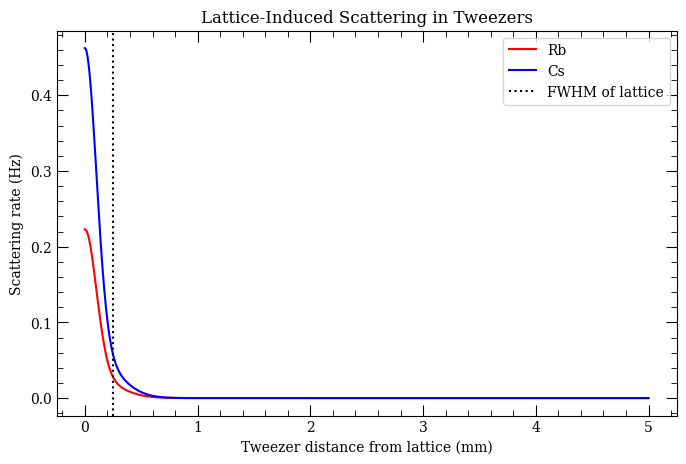

In [11]:
def pos_dep_lattice_scatter(r, tweezer_z, focus, transport_distance, power, waist, wavelength):
    Ir_tot_r = I_tot(tweezer_z, focus, r, transport_distance, power=power, w0=waist, wavelength=wavelength)
    lattice_frequency = c/wavelength
    Rb_R_D2_tweezer_fromlattice = calc_scattering_rate(Ir_tot_r, Rb_D2_pi_Isat, lattice_frequency-Rb_D2freq_in_tweezer, Rb_D2_gamma)
    Cs_R_D2_tweezer_fromlattice = calc_scattering_rate(Ir_tot_r, Cs_D2_pi_Isat, lattice_frequency-Cs_D2freq_in_tweezer, Cs_D2_gamma)
    return Rb_R_D2_tweezer_fromlattice, Cs_R_D2_tweezer_fromlattice

power = 18  # power in Watts
waist = 180e-6  # beam waist in meters
transport_distance = 37e-2 # 37 cm from MOT to tweezers
focus = 0.09  # focus position in meters
wavelength = 1064e-9 # 1064 nm
tweezer_z = 43.5e-3 - 0.5e-3 # tweezers are in center of glass cell which is 87 mm wide
r_array = np.linspace(0e-3, 5e-3, 1000) #tweezers 0.5mm to 10mm from lattice
Rb_f = [] ; Cs_f = []
for r in r_array:
    Rb_f_temp, Cs_f_temp = pos_dep_lattice_scatter(r, tweezer_z, focus, transport_distance, power, waist, wavelength)
    Rb_f.append(Rb_f_temp)
    Cs_f.append(Cs_f_temp)
Rb_f = np.array(Rb_f)
Cs_f = np.array(Cs_f)
plt.figure(figsize=(8,5))
plt.ylabel("Scattering rate (Hz)")
plt.xlabel("Tweezer distance from lattice (mm)")
plt.plot(r_array*1e3, Rb_f, color='red', label='Rb')
plt.plot(r_array*1e3, Cs_f, color='blue', label='Cs')
plt.axvline(0.25, color='black', linestyle='dotted', label = "FWHM of lattice")
plt.legend()
plt.title("Lattice-Induced Scattering in Tweezers")

## Atom Array 2 Recreation

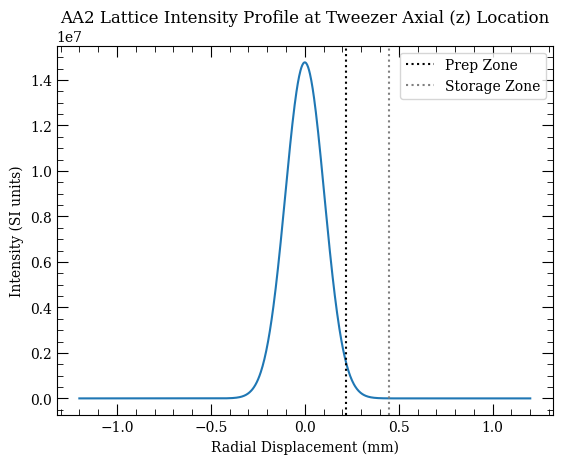

In [65]:
# Values from their paper
aa2_rbdetuning = 300e9 # AA2 does near-detuned (300GHz) transport from the D1 line
aa2_power = 1 # 1 Watt
aa2_waist = 150e-6 # minimum waist of 150 um
aa2_distance = (17e-2)/2 # assume the tweezers are 17 cm/2 from the focus of the lattice beam
aa2_focus = 0 # assume the tweezers are 17 cm/2 from the focus of the lattice beam
aa2_latticetoprep = 220e-6 #220 um from lattice to preparation tweezers
aa2_latticetostorage = 450e-6 #~450 um from lattice to storage tweezers

# Calculated values
aa2_latticefrequency = Rb_D1_frequency - aa2_rbdetuning
aa2_latticewavelength = c/aa2_latticefrequency

# we expect trap depth of > 500uK
r_array = np.linspace(-aa2_waist*8, aa2_waist*8, 1000)
aa2_Ir = I_slice(aa2_distance, aa2_focus, r_array, power=aa2_power, w0=aa2_waist, wavelength=aa2_latticewavelength)
plt.plot(r_array*1e3, aa2_Ir)
plt.title("AA2 Lattice Intensity Profile at Tweezer Axial (z) Location")
plt.ylabel("Intensity (SI units)")
plt.xlabel("Radial Displacement (mm)")
plt.axvline(aa2_latticetoprep*1e3, color='black', linestyle='dotted', label='Prep Zone')
plt.axvline(aa2_latticetostorage*1e3, color='gray', linestyle='dotted', label='Storage Zone')
plt.legend()

In [60]:
# T2 effects
aa2_Ir_prep = I_slice(aa2_distance, aa2_focus, aa2_latticetoprep, power=aa2_power, w0=aa2_waist, wavelength=aa2_latticewavelength)
aa2_Ir_storage = I_slice(aa2_distance, aa2_focus, aa2_latticetostorage, power=aa2_power, w0=aa2_waist, wavelength=aa2_latticewavelength)

NA = 0.65 # Objective NA
Rb_tweezer_power = 722e-6 #722uW
Rb_tweezer_waist = Rb_tweezer_wavelength / (np.pi*NA)
Rb_peak_intensity = (2*Rb_tweezer_power)/(np.pi*Rb_tweezer_waist**2)
print(f"Rubidium tweezer waist = {Rb_tweezer_waist*1e6} um")
print(f"Rubidium tweezer peak intensity = {Rb_peak_intensity/1e9} GW/m^2")
print(f"For AA2 tweezered atoms in prep zone :")
print(f"(Rb tweezer intensity/lattice intensity) = {Rb_peak_intensity/aa2_Ir_prep}")
print(f"For AA2 tweezered atoms in science zone :")
print(f"(Rb tweezer intensity/lattice intensity) = {Rb_peak_intensity/aa2_Ir_storage}")

Rubidium tweezer waist = 0.39617338141951797 um
Rubidium tweezer peak intensity = 2.928510166114214 GW/m^2
For AA2 tweezered atoms in prep zone :
(Rb tweezer intensity/lattice intensity) = 1873.7348527415759
For AA2 tweezered atoms in science zone :
(Rb tweezer intensity/lattice intensity) = 2391330.735892203


In [67]:
# T1 effects
Rb_D1_scatter_prep = calc_scattering_rate(aa2_Ir_prep, Rb_D1_pi_Isat, aa2_rbdetuning, Rb_D1_gamma)
Rb_D1_scatter_storage = calc_scattering_rate(aa2_Ir_storage, Rb_D1_pi_Isat, aa2_rbdetuning, Rb_D1_gamma)
print(f"Rb87 scattering rate in tweezers off D1 line from AA2 lattice light in prep zone (photons/s): {Rb_D1_scatter_prep}")
print(f"Rb87 scattering rate in tweezers off D1 line from AA2 lattice light in storage zone (photons/s): {Rb_D1_scatter_storage}")

Rb87 scattering rate in tweezers off D1 line from AA2 lattice light in prep zone (photons/s): 57.70531891900776
Rb87 scattering rate in tweezers off D1 line from AA2 lattice light in storage zone (photons/s): 0.04521533177940523
